In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from catboost import CatBoostClassifier, Pool
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
import warnings
warnings.filterwarnings('ignore')

train = pd.read_csv('/Users/Jiyeon/Desktop/ftp/fertility-treatment-prediction/data/raw/train.csv')
test  = pd.read_csv('/Users/Jiyeon/Desktop/ftp/fertility-treatment-prediction/data/raw/test.csv')

TARGET = '임신 성공 여부'
ID_COL = 'ID'

print('Train:', train.shape, '/ Test:', test.shape)
print('타겟 분포:')
print(train[TARGET].value_counts(normalize=True).round(3))

Train: (256351, 69) / Test: (90067, 68)
타겟 분포:
임신 성공 여부
0    0.742
1    0.258
Name: proportion, dtype: float64


In [2]:
# 피처 준비
# 제거할 컬럼
DROP_COLS = [TARGET, ID_COL]

# 피처 컬럼
feat_cols = [c for c in train.columns if c not in DROP_COLS]

X = train[feat_cols].copy()
y = train[TARGET].copy()
X_test = test[feat_cols].copy()

# 범주형 컬럼 자동 탐지 (CatBoost에 전달)
cat_features = [c for c in feat_cols if X[c].dtype == 'object']

# CatBoost는 범주형을 문자열로 받아야 함
for col in cat_features:
    X[col]      = X[col].astype(str).fillna('missing')
    X_test[col] = X_test[col].astype(str).fillna('missing')

# scale_pos_weight: 음성/양성 비율
neg = (y == 0).sum()
pos = (y == 1).sum()
spw = neg / pos

print(f'피처 수: {len(feat_cols)}개 (범주형: {len(cat_features)}개)')
print(f'scale_pos_weight: {spw:.2f} (음성 {neg}건 / 양성 {pos}건)')

피처 수: 67개 (범주형: 0개)
scale_pos_weight: 2.87 (음성 190123건 / 양성 66228건)


In [3]:
# StratifiedKFold 학습 + OOF 예측
N_SPLITS = 5
SEED     = 42

cat_features = X.select_dtypes(include=['object','category']).columns.tolist()

for col in cat_features:
    X[col] = X[col].astype(str).fillna('missing')
    X_test[col] = X_test[col].astype(str).fillna('missing')

skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)

oof_preds  = np.zeros(len(X))
test_preds = np.zeros(len(X_test))
fold_scores = []
models = []

# CatBoost 파라미터 (베이스라인)
params = dict(
    iterations         = 1000,
    learning_rate      = 0.05,
    depth              = 6,
    loss_function      = 'Logloss',
    eval_metric        = 'AUC',
    scale_pos_weight   = spw,
    random_seed        = SEED,
    early_stopping_rounds = 50,
    verbose            = False,
    use_best_model     = True,
)

for fold, (tr_idx, val_idx) in enumerate(skf.split(X, y)):
    X_tr, X_val = X.iloc[tr_idx], X.iloc[val_idx]
    y_tr, y_val = y.iloc[tr_idx], y.iloc[val_idx]

    train_pool = Pool(X_tr, y_tr, cat_features=cat_features)
    val_pool   = Pool(X_val, y_val, cat_features=cat_features)
    test_pool  = Pool(X_test, cat_features=cat_features)

    model = CatBoostClassifier(**params)
    model.fit(train_pool, eval_set=val_pool)

    val_pred  = model.predict_proba(val_pool)[:, 1]
    fold_auc  = roc_auc_score(y_val, val_pred)

    oof_preds[val_idx]  = val_pred
    test_preds         += model.predict_proba(test_pool)[:, 1] / N_SPLITS
    fold_scores.append(fold_auc)
    models.append(model)

    print(f'Fold {fold+1} | AUC: {fold_auc:.5f} | Best iter: {model.best_iteration_}')

oof_auc = roc_auc_score(y, oof_preds)
print(f'\n✅ OOF AUC : {oof_auc:.5f}')
print(f'   Fold 평균: {np.mean(fold_scores):.5f} ± {np.std(fold_scores):.5f}')

Fold 1 | AUC: 0.73850 | Best iter: 586
Fold 2 | AUC: 0.74294 | Best iter: 535
Fold 3 | AUC: 0.74042 | Best iter: 753
Fold 4 | AUC: 0.73814 | Best iter: 453
Fold 5 | AUC: 0.73999 | Best iter: 367

✅ OOF AUC : 0.73999
   Fold 평균: 0.74000 ± 0.00170


=== 피처 중요도 Top 30 ===


,feature,importance
0,이식된 배아 수,55.091895
1,배아 이식 경과일,9.194417
2,시술 당시 나이,5.509453
3,저장된 배아 수,4.802460
4,난자 채취 경과일,4.109196
5,총 생성 배아 수,3.164565
6,수집된 신선 난자 수,2.914464
7,난자 출처,2.259209
8,배란 유도 유형,1.406501
9,배아 생성 주요 이유,1.040674


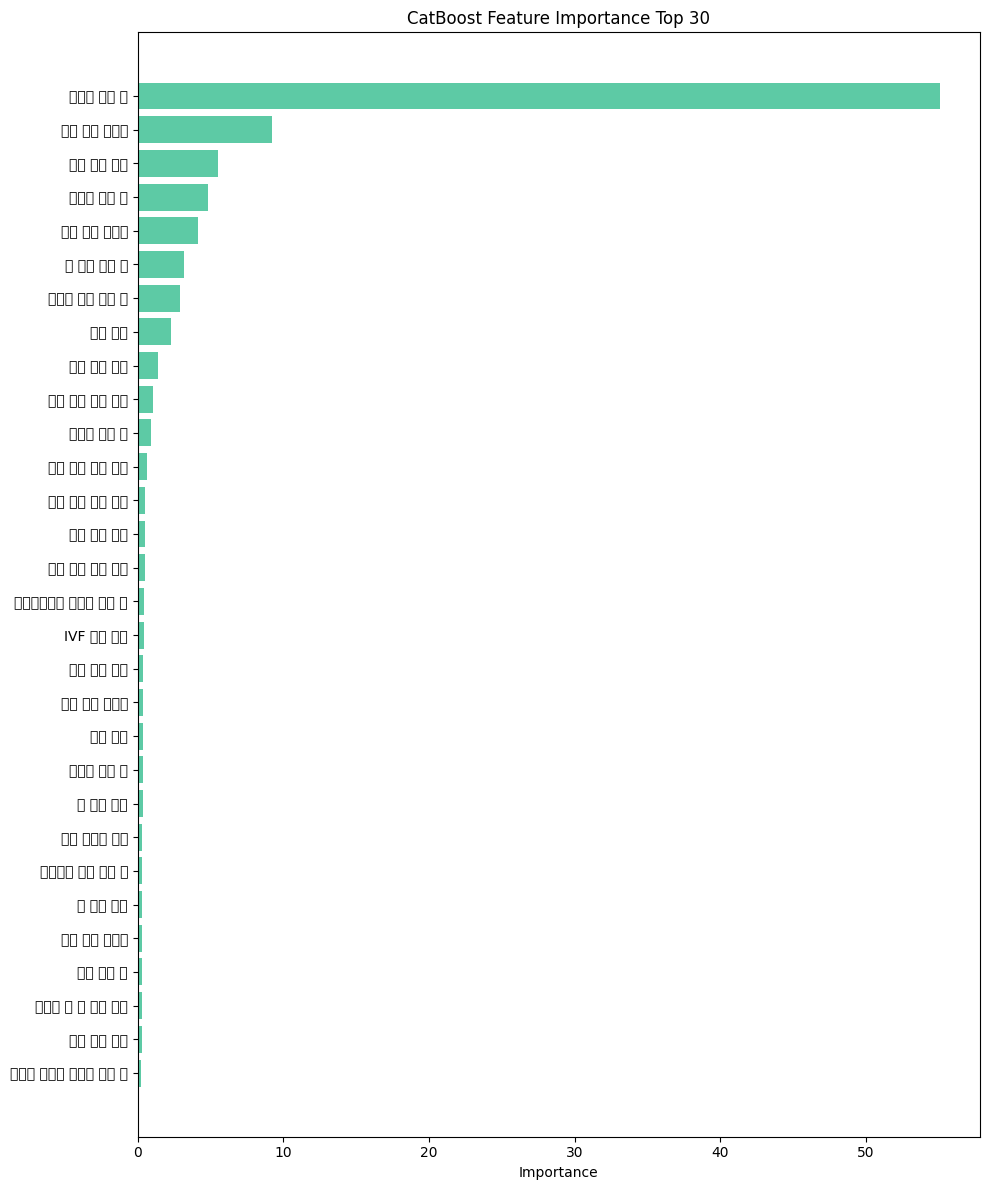


중요도 0 피처 (1개): ['불임 원인 - 여성 요인']


In [4]:
# 피처 중요도 확인
# 전체 fold 평균 피처 중요도
importance = np.mean(
    [m.get_feature_importance() for m in models], axis=0
)
fi = pd.DataFrame({
    'feature': feat_cols,
    'importance': importance
}).sort_values('importance', ascending=False).reset_index(drop=True)

print('=== 피처 중요도 Top 30 ===')
display(fi.head(30))

# 시각화
fig, ax = plt.subplots(figsize=(10, 12))
top = fi.head(30)
ax.barh(top['feature'][::-1], top['importance'][::-1], color='#5DCAA5')
ax.set_title('CatBoost Feature Importance Top 30')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()

# 중요도 0인 피처 확인 (제거 후보)
zero_imp = fi[fi['importance'] == 0]['feature'].tolist()
print(f'\n중요도 0 피처 ({len(zero_imp)}개): {zero_imp}')

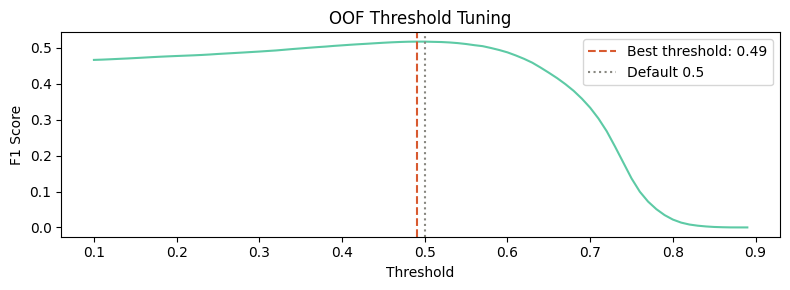

Best threshold (F1 기준): 0.49
※ 데이콘 평가가 ROC-AUC면 threshold는 제출에 영향 없음


In [5]:
# Threshold 튜닝(참고용)
from sklearn.metrics import f1_score

thresholds = np.arange(0.1, 0.9, 0.01)
f1_scores  = [f1_score(y, (oof_preds >= t).astype(int)) for t in thresholds]
best_t     = thresholds[np.argmax(f1_scores)]

plt.figure(figsize=(8, 3))
plt.plot(thresholds, f1_scores, color='#5DCAA5')
plt.axvline(best_t, color='#D85A30', linestyle='--', label=f'Best threshold: {best_t:.2f}')
plt.axvline(0.5, color='#888780', linestyle=':', label='Default 0.5')
plt.xlabel('Threshold')
plt.ylabel('F1 Score')
plt.title('OOF Threshold Tuning')
plt.legend()
plt.tight_layout()
plt.show()

print(f'Best threshold (F1 기준): {best_t:.2f}')
print('※ 데이콘 평가가 ROC-AUC면 threshold는 제출에 영향 없음')

In [6]:
# 제출 파일 생성
submission = pd.DataFrame({
    ID_COL: test[ID_COL],
    TARGET: test_preds
})

submission.to_csv('submission_catboost_baseline.csv', index=False, encoding='utf-8-sig')
print('저장 완료: submission_catboost_baseline.csv')
print(f'OOF AUC: {oof_auc:.5f}')
display(submission.head())

저장 완료: submission_catboost_baseline.csv
OOF AUC: 0.73999


,ID,임신 성공 여부
0,TEST_00000,0.004552
1,TEST_00001,0.016398
2,TEST_00002,0.344626
3,TEST_00003,0.255303
4,TEST_00004,0.729244
